In [ ]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install tensorflow
!pip install kagglehub
!pip install scikit-learn
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install optuna
!pip install scipy

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import random
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import seaborn as sb
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import plotly.express as px

In [ ]:
path = kagglehub.dataset_download("patrickzel/flight-delay-and-cancellation-dataset-2019-2023")
file_path = os.path.join(path, "flights_sample_3m.csv")
data = pd.read_csv(file_path)
pd.set_option('display.max_columns', None)
display(data)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,2022-11-13,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1522,JAX,"Jacksonville, FL",CLT,"Charlotte, NC",1742,1740.0,-2.0,10.0,1750.0,1845.0,6.0,1907,1851.0,-16.0,0.0,NaN,0.0,85.0,71.0,55.0,328.0,NaN,NaN,NaN,NaN,NaN
2999996,2022-11-02,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1535,ORD,"Chicago, IL",AUS,"Austin, TX",1300,1254.0,-6.0,10.0,1304.0,1514.0,5.0,1556,1519.0,-37.0,0.0,NaN,0.0,176.0,145.0,130.0,977.0,NaN,NaN,NaN,NaN,NaN
2999997,2022-09-11,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2745,HSV,"Huntsville, AL",ATL,"Atlanta, GA",534,615.0,41.0,16.0,631.0,759.0,6.0,729,805.0,36.0,0.0,NaN,0.0,55.0,50.0,28.0,151.0,0.0,36.0,0.0,0.0,0.0
2999998,2019-11-13,Republic Airline,Republic Airline: YX,YX,20452,6134,BOS,"Boston, MA",LGA,"New York, NY",1600,1555.0,-5.0,19.0,1614.0,1704.0,8.0,1728,1712.0,-16.0,0.0,NaN,0.0,88.0,77.0,50.0,184.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
#data description
# Use os.path.join to correctly construct the file path
file_path_html = os.path.join(path, 'dictionary.html')
with open(file_path_html, 'r') as file:
    html_content = file.read()
display(HTML(html_content))

Updated Header,Source Header,Data Type,Description
FL_DATE,FlightDate,object,Flight Date (yyyymmdd)
AIRLINE_CODE,Reporting_Airline,object,"Unique Carrier Code. When the same code has been used by multiple carriers, a numeric suffix is used for earlier users, for example, PA, PA(1), PA(2). Use this field for analysis across a range of years."
DOT_CODE,DOT_ID_Reporting_Airline,int64,"An identification number assigned by US DOT to identify a unique airline (carrier). A unique airline (carrier) is defined as one holding and reporting under the same DOT certificate regardless of its Code, Name, or holding company/corporation."
FL_NUMBER,Flight_Number_Reporting_Airline,int64,Flight Number
ORIGIN,Origin,object,Origin Airport
ORIGIN_CITY,OriginCityName,object,"Origin Airport, City Name"
DEST,Dest,object,Destination Airport
DEST_CITY,DestCityName,object,"Destination Airport, City Name"
CRS_DEP_TIME,CRSDepTime,int64,CRS Departure Time (local time: hhmm)
DEP_TIME,DepTime,float64,Actual Departure Time (local time: hhmm)


In [ ]:
data['FL_DATE'] = pd.to_datetime(data['FL_DATE'], format='%Y-%m-%d').copy()

In [ ]:
data.describe()

,FL_DATE,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3000000,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,2.920058e+06,2.913802e+06,3.000000e+06,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,2021-05-07 18:03:59.616002048,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,1.466511e+03,4.260858e+00,2.638000e-02,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
min,2019-01-01 00:00:00,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019-12-28 00:00:00,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,1.053000e+03,-1.600000e+01,0.000000e+00,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021-06-28 00:00:00,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,1.505000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2022-08-02 00:00:00,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,1.913000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2023-08-31 00:00:00,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,2.400000e+03,2.934000e+03,1.000000e+00,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000
std,NaN,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,5.318383e+02,5.117482e+01,1.602626e-01,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892


In [ ]:
TEST: bool = True

Dropping cancelled and diverted flights, they are outside of our scope, we only want delayed flights

In [ ]:
num_cancelled_or_diverted = len(data[(data['CANCELLED'] == 1) | (data['DIVERTED'] == 1)])
cancelled_or_diverted_counts = data[(data['CANCELLED'] == 1) | (data['DIVERTED'] == 1)]["FL_DATE"].dt.strftime('%Y-%m').value_counts().sort_index()
data = data[(data['CANCELLED'] != 1) & (data['DIVERTED'] != 1)]

Attempt to drop duplicates (we found out there aren't any)

In [ ]:
data_len_with_duplicates = len(data)
data.drop_duplicates(inplace=True)
if TEST:
  assert len(data) == data_len_with_duplicates  # no duplicates

Visualizing the presence of delay components

In [ ]:
def split_by_components(df: pd.DataFrame):
  # Finding: if there is one component, it has all components
  isna_mask = df[['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
                  'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
                  'DELAY_DUE_LATE_AIRCRAFT']].isna().any(axis=1)

  delay_components_df = df[~isna_mask]
  no_delay_components_df = df[isna_mask]

  return delay_components_df, no_delay_components_df

(np.float64(-1.099999862662219),
 np.float64(1.0999998952506516),
 np.float64(-1.099999898466608),
 np.float64(1.0999999951650765))

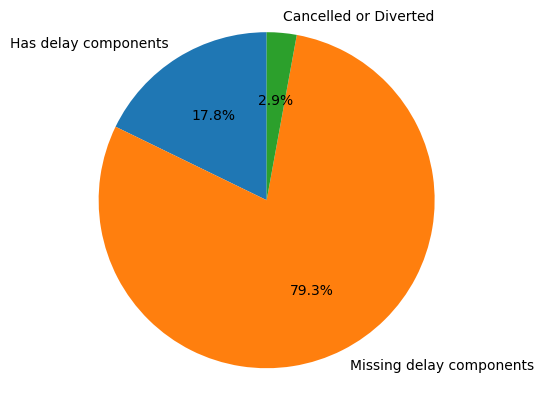

In [ ]:
delay_components_df, no_delay_components_df = split_by_components(data)

ratio_components = len(delay_components_df) / len(data)

fig, ax = plt.subplots()
labels = ["Has delay components", "Missing delay components", "Cancelled or Diverted"]
sizes = [len(delay_components_df), len(no_delay_components_df), num_cancelled_or_diverted]
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.axis('equal')

About 79.3% data does not contain any reason for the delay and hence we can't use that

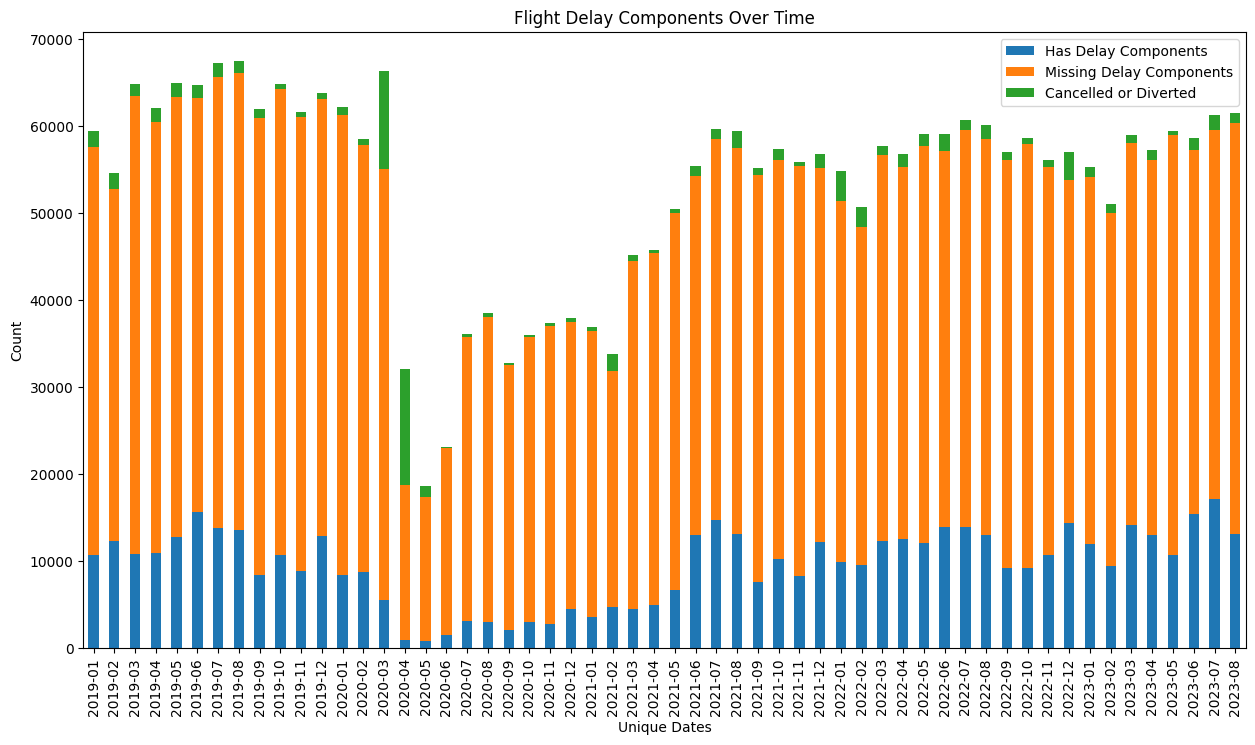

In [ ]:
components_counts = delay_components_df["FL_DATE"].dt.strftime('%Y-%m').value_counts().sort_index()
no_components_counts = no_delay_components_df["FL_DATE"].dt.strftime('%Y-%m').value_counts().sort_index()
all_dates = pd.concat([components_counts, no_components_counts, cancelled_or_diverted_counts], axis=1, keys=['Components', 'No Components', "Cancelled or Diverted"])
all_dates.reset_index(inplace=True)
all_dates.columns = ['Date', 'Has Delay Components', 'Missing Delay Components', "Cancelled or Diverted"]

fig, ax = plt.subplots(figsize=(15, 8))
all_dates.set_index('Date').plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Unique Dates')
ax.set_ylabel('Count')
ax.set_title('Flight Delay Components Over Time')
plt.xticks(rotation=90)
plt.show()

Ensure that delay components always sum to equal arrival delay

In [ ]:
if TEST:
  def check_delay_components_sum_to_arr_delay(row) -> bool:
      components_delay = row[['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
                            'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
                            'DELAY_DUE_LATE_AIRCRAFT']].sum()
      return components_delay == row['ARR_DELAY']

  assert delay_components_df.apply(check_delay_components_sum_to_arr_delay, axis=1).all()

Set data to just the delay components to simplify referencing below

In [ ]:
data = delay_components_df.copy()

Removing outliers using IQR method

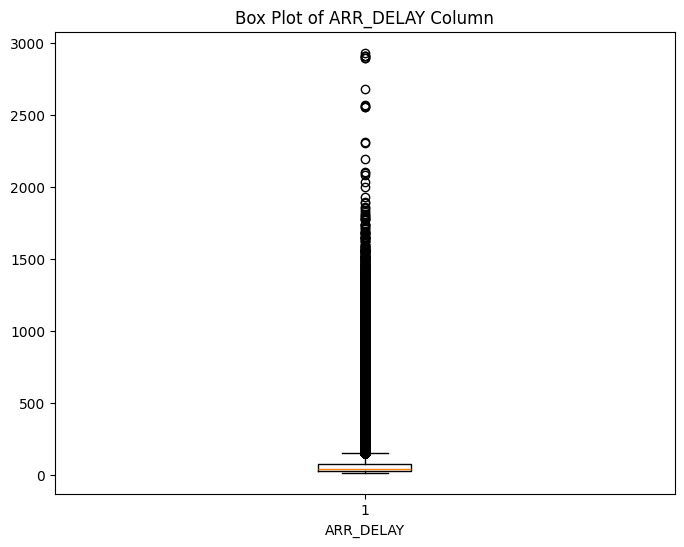

Summary Statistics after Removing Outliers:
count    489828.000000
mean         47.827962
std          32.868451
min          15.000000
25%          23.000000
50%          36.000000
75%          63.000000
max         154.000000
Name: ARR_DELAY, dtype: float64
count    533863.000000
mean         67.526287
std          93.909364
min          15.000000
25%          24.000000
50%          39.000000
75%          76.000000
max        2934.000000
Name: ARR_DELAY, dtype: float64
0.0824837083671279
44035


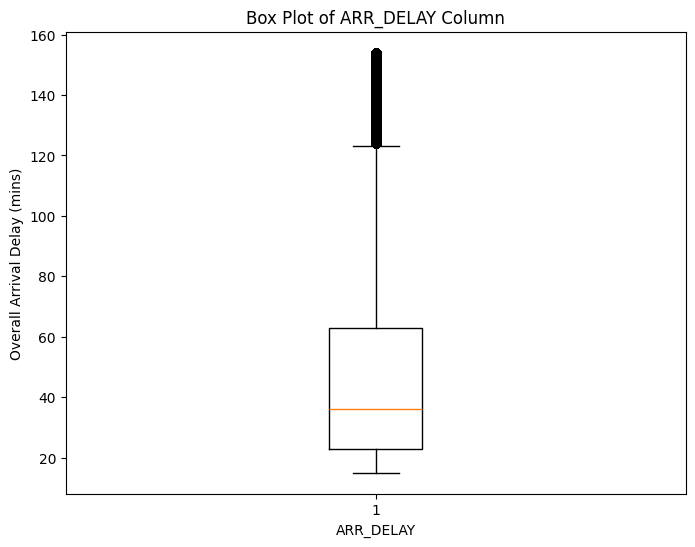

In [ ]:
# Boxplot before removing outliers
plt.figure(figsize=(8, 6))
plt.boxplot(data['ARR_DELAY'])
plt.title('Box Plot of ARR_DELAY Column')
plt.xlabel('ARR_DELAY')
plt.show()

# Calculate Q1, Q3, IQR
Q1 = data['ARR_DELAY'].quantile(0.25)
Q3 = data['ARR_DELAY'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
data_no_outliers = data[(data['ARR_DELAY'] >= lower_bound) & (data['ARR_DELAY'] <= upper_bound)]

print("Summary Statistics after Removing Outliers:")
print(data_no_outliers['ARR_DELAY'].describe())
print(data["ARR_DELAY"].describe())

print((len(data) - len(data_no_outliers)) / len(data))
print((len(data) - len(data_no_outliers)))

# Box plot after removing outliers
plt.figure(figsize=(8, 6))
plt.boxplot(data_no_outliers['ARR_DELAY'])
plt.title('Box Plot of ARR_DELAY Column')
plt.xlabel('ARR_DELAY')
plt.ylabel("Overall Arrival Delay (mins)")
plt.show()

Pearson correlation

In [ ]:
from scipy.stats import pearsonr

def calculate_pearson_score(df: pd.DataFrame, col: str, y) -> float:
  """
  Calculates the Pearson correlation coefficient between two columns in a DataFrame.

  Args:
    df: DataFrame.
    col: The name of the first column.
    y: The name of the second column.

  Returns:
    Pearson correlation coefficient.
  """
  try:
    corr,_ = pearsonr(df[col].values, y.values)
    return corr
  except:
    return 0

# Calculate the Pearson correlation coefficient for each column w/ ARR_DELAY
pearson_scores = {}


cols = ['CRS_DEP_TIME', 'TAXI_OUT', 'TAXI_IN', 'CRS_ARR_TIME',
        'CRS_ELAPSED_TIME', 'DISTANCE', 'DEP_DELAY', 'WHEELS_OFF',
        'WHEELS_ON', 'AIR_TIME', 'ELAPSED_TIME']
for col in cols:
    pearson_scores[col] = calculate_pearson_score(data_no_outliers, col, data_no_outliers["ARR_DELAY"])

# Sort the Pearson correlation coefficients
sorted_pearson_scores = sorted(pearson_scores.items(), key=lambda x: x[1], reverse=True)

for col, score in sorted_pearson_scores:
    print(f"{col}: {score}")

# NOTE: ELAPSED TIME IS REDUNDANT

DEP_DELAY: 0.8558020929813213
WHEELS_OFF: 0.10200029622960391
CRS_DEP_TIME: 0.07035140013690293
TAXI_OUT: 0.0541060512760234
CRS_ARR_TIME: 0.050028470402502724
TAXI_IN: 0.023541680857308435
ELAPSED_TIME: -0.010629234164684535
CRS_ELAPSED_TIME: -0.012206498859525669
WHEELS_ON: -0.02090029161556632
DISTANCE: -0.022838335188191408
AIR_TIME: -0.025517391209942675


In [ ]:

from scipy.stats import kruskal

# Create month and day of week
data_no_outliers['MONTH'] = data_no_outliers['FL_DATE'].dt.month
data_no_outliers['DAY_OF_WEEK'] = data_no_outliers['FL_DATE'].dt.dayofweek

cols = ['AIRLINE', 'FL_NUMBER', 'ORIGIN', 'DEST', 'MONTH', 'DAY_OF_WEEK']

h_values = {}
p_values = {}

for col in cols:
    groups = [group['ARR_DELAY'].dropna() for name, group in data_no_outliers.groupby(col)]
    if all(len(g) > 0 for g in groups):
        h, p_value = kruskal(*groups)
        h_values[col] = h
        p_values[col] = p_value
    else:
        h_values[col] = 0
        p_values[col] = 1

sorted_cols = sorted(h_values, key=h_values.get, reverse=True)

for col in sorted_cols:
    print(f"{col}: H = {h_values[col]:.2f}, p = {p_values[col]:.3e}")


/tmp/ipython-input-89-857515800.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-89-857515800.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



FL_NUMBER: H = 8809.14, p = 1.016e-54
AIRLINE: H = 4954.99, p = 0.000e+00
ORIGIN: H = 4605.39, p = 0.000e+00
DEST: H = 3988.84, p = 0.000e+00
MONTH: H = 1850.93, p = 0.000e+00
DAY_OF_WEEK: H = 91.88, p = 1.230e-17


In [ ]:
# prompt: I want the data_no_outliers to be sorted in ascending order of FL_DATE

data_no_outliers = data_no_outliers.sort_values(by='FL_DATE', ascending=True)

In [ ]:
X_df = data_no_outliers[
    [
        "FL_DATE",  # yyymmdd of flight (ordinal, discrete),
        "FL_NUMBER",
        "AIRLINE",  # name of airline (nominal, discrete)
        # Ignore AIRLINE_CODE because it is redundant
        "ORIGIN",  # origin airport code (nomincal, discrete)
        # Ignore ORIGIN_CITY because it is redundant
        "DEST",  # destination airport code (nomincal, discrete)
        # Ignore DEST_CITY because it is redundant
        "CRS_DEP_TIME",  # hhmm planned departure time (ordinal, discrete)
        "CRS_ARR_TIME",  # hhmm planned arrival time (ordinal, discrete)
        # Ignore CRS_ELAPSED_TIME because it is redundant since we have CRS_DEP_TIME and CRS_ARR_TIME
        "DISTANCE",  # miles between airports (ratio, discrete)
        "TAXI_IN",
        "TAXI_OUT"
    ]
]

Y_df = data_no_outliers[
    [
        # "CANCELLATION_CODE",  # reason for cancellation, NA if not cancelled (nominal, discrete)
        # Ignore CANCELLED because it is redundant, CANCELLATION_CODE provides more information
        # "DIVERTED",  # 1 if diverted, 0 if not (ordinal, discrete) NOTE: NOT SURE IF WE WANT TO KEEP
        # "AIR_TIME",  # Flight time, minutes (ratio, discrete)
        "DELAY_DUE_CARRIER",  # delay due to technical difficulties / damage / carrier efficiency (ratio, discrete)
        # Hypothesis: AIRLINE, ORIGIN, DEST may inform DELAY_DUE_CARRIER
        "DELAY_DUE_WEATHER",  # delay due to weather (ratio, discrete)
        # Hypothesis: FL_DATE, ORIGIN, DEST may inform DELAY_DUE_WEATHER
        "DELAY_DUE_SECURITY",  # delay due to security (ratio, discrete)
        # Hypothesis: FL_DATE, ORIGIN, CRS_DEP_TIME, DISTANCE may inform DELAY_DUE_SECURITY,
        "DELAY_DUE_NAS",  # not sure how this will do due to lacking info in features
        "DELAY_DUE_LATE_AIRCRAFT"  # delay due to late aircraft (ratio, discrete)
        # Hypothesis: AIRLINE, CRS_DEP_TIME may inform DELAY_DUE_LATE_AIRCRAFT
    ]
]

arr_only_y_df = data_no_outliers["ARR_DELAY"]

# AIRLINE_CODE, DOT_CODE, FL_NUMBER are ignored because they are unique identifiers
# TAXI_OUT, WHEELS_OFF, WHEELS_ON, TAXI_IN are ignored because they seem irrelevant NOTE: MAY WANT TO LOOK INTO THIS
# DEP_TIME, DEP_DELAY, ARR_TIME, ARR_DELAY, ELAPSED_TIME are ignored because the individual delay contributions factor into them

# WARNING: DELAY_DUE_NAS might not have sufficient info to predict this. It is National Air System Delay, minutes.

In [ ]:
X_df.to_csv("X_df.csv", index=False)
Y_df.to_csv("Y_df.csv", index=False)
arr_only_y_df.to_csv("arr_only_y_df.csv", index=False)

In [ ]:
df = data.copy()

In [ ]:
# Look for any NA values in X
if TEST:
  X_df.replace('', np.nan, inplace=True)
  pd.isna(X_df).sum().sum() == 0

/tmp/ipython-input-124-3653023300.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Label encoding the airline and airport. ORIGIN and DEST should be encoded together to preserve the relationship between outbound and inbound same airports.

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
import pandas as pd

# Assign integer labels to airline
airline_encoder = LabelEncoder()
X_df["AIRLINE"] = airline_encoder.fit_transform(X_df["AIRLINE"])

# Assign integer labels to airport code
airport_encoder = LabelEncoder()
# Use pd.concat to combine the 'ORIGIN' and 'DEST' columns
airport_encoder.fit(pd.concat([X_df["ORIGIN"], X_df["DEST"]]))
X_df["ORIGIN"] = airport_encoder.transform(X_df["ORIGIN"])
X_df["DEST"] = airport_encoder.transform(X_df["DEST"])
# assert X_df.loc[1, "ORIGIN"] == X_df.loc[3, "ORIGIN"] == X_df.loc[2, "DEST"]  # all MSP

X_df.head()

/tmp/ipython-input-125-2428774149.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-125-2428774149.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-125-2428774149.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,FL_DATE,FL_NUMBER,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT
2358641,2019-01-01,5795,11,100,276,1825,2013,868.0,9.0,17.0
2123710,2019-01-01,1396,15,61,49,2030,2200,369.0,8.0,21.0
2344858,2019-01-01,2180,2,261,276,825,1121,1440.0,10.0,16.0
797324,2019-01-01,2465,2,261,199,2030,2237,1514.0,6.0,14.0
806623,2019-01-01,210,2,234,276,1350,1659,1972.0,8.0,15.0


Converting hhmm time format to minutes past midnight, this way it'll help us run our models easily, instead of going to a datetime format and then again calculating the time difference in minutes/hours.

In [ ]:
def convert_hhmm_to_mins(hhmm_list):
  hours = []
  mins = []

  # Look at str length to determine number of hours and mins
  for s in hhmm_list:
    if len(s) == 1:
      hours.append(0)
      mins.append(int(s))
    elif len(s) == 2:
      hours.append(0)
      mins.append(int(s))
    elif len(s) == 3:
      hours.append(int(s[0]))
      mins.append(int(s[1:]))
    elif len(s) == 4:
        hours.append(int(s[:2]))
        mins.append(int(s[2:]))
    else:
      raise ValueError(s)

  # Calculate total minutes
  return np.array(hours) * 60 + np.array(mins)

# Convert hhmm times to minutes
X_df["CRS_DEP_TIME"] = X_df["CRS_DEP_TIME"].astype(str)
X_df["CRS_DEP_TIME"] = convert_hhmm_to_mins(X_df["CRS_DEP_TIME"])
# assert X_df["CRS_DEP_TIME"][:5].tolist() == [715, 1280, 594, 969, 1120]

X_df["CRS_ARR_TIME"] = X_df["CRS_ARR_TIME"].astype(str)
X_df["CRS_ARR_TIME"] = convert_hhmm_to_mins(X_df["CRS_ARR_TIME"])
# assert X_df["CRS_ARR_TIME"][:5].tolist() == [901, 1395, 772, 1109, 1241]

X_df.head()

/tmp/ipython-input-126-3880266324.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-126-3880266324.py:27: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-126-3880266324.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ip

,FL_DATE,FL_NUMBER,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT
2358641,2019-01-01,5795,11,100,276,1105,1213,868.0,9.0,17.0
2123710,2019-01-01,1396,15,61,49,1230,1320,369.0,8.0,21.0
2344858,2019-01-01,2180,2,261,276,505,681,1440.0,10.0,16.0
797324,2019-01-01,2465,2,261,199,1230,1357,1514.0,6.0,14.0
806623,2019-01-01,210,2,234,276,830,1019,1972.0,8.0,15.0


In [ ]:


# Convert distance to int, its already an int basically
X_df["DISTANCE"] = X_df["DISTANCE"].astype(int)
X_df.head()



/tmp/ipython-input-127-1279960313.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,FL_DATE,FL_NUMBER,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT
2358641,2019-01-01,5795,11,100,276,1105,1213,868,9.0,17.0
2123710,2019-01-01,1396,15,61,49,1230,1320,369,8.0,21.0
2344858,2019-01-01,2180,2,261,276,505,681,1440,10.0,16.0
797324,2019-01-01,2465,2,261,199,1230,1357,1514,6.0,14.0
806623,2019-01-01,210,2,234,276,830,1019,1972,8.0,15.0


In [ ]:
# Convert FL_DATE column to datetime
X_df['FL_DATE'] = pd.to_datetime(X_df['FL_DATE'])

X_df['YEAR'] = X_df['FL_DATE'].dt.year
X_df['MONTH'] = X_df['FL_DATE'].dt.month
X_df['DAY'] = X_df['FL_DATE'].dt.day

# Drop the original column
X_df.drop(columns=['FL_DATE'], inplace=True)

if TEST:
    assert X_df["MONTH"].min() == 1
    assert X_df["MONTH"].max() == 12
    assert X_df["DAY"].min() == 1
    assert X_df["DAY"].max() == 31

X_df.head()

/tmp/ipython-input-128-2737446006.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-128-2737446006.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-128-2737446006.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipyth

,FL_NUMBER,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR,MONTH,DAY
2358641,5795,11,100,276,1105,1213,868,9.0,17.0,2019,1,1
2123710,1396,15,61,49,1230,1320,369,8.0,21.0,2019,1,1
2344858,2180,2,261,276,505,681,1440,10.0,16.0,2019,1,1
797324,2465,2,261,199,1230,1357,1514,6.0,14.0,2019,1,1
806623,210,2,234,276,830,1019,1972,8.0,15.0,2019,1,1


In [ ]:


X_df.drop(columns=["FL_NUMBER"], inplace=True)
X_df



/tmp/ipython-input-129-490899618.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR,MONTH,DAY
2358641,11,100,276,1105,1213,868,9.0,17.0,2019,1,1
2123710,15,61,49,1230,1320,369,8.0,21.0,2019,1,1
2344858,2,261,276,505,681,1440,10.0,16.0,2019,1,1
797324,2,261,199,1230,1357,1514,6.0,14.0,2019,1,1
806623,2,234,276,830,1019,1972,8.0,15.0,2019,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2280075,15,201,199,1275,1345,236,11.0,33.0,2023,8,31
2054645,15,47,199,1290,1400,1587,7.0,11.0,2023,8,31
1829970,2,23,234,1076,1200,594,14.0,29.0,2023,8,31
1929122,15,26,199,1135,1180,1090,5.0,11.0,2023,8,31


In [ ]:
X_df["TAXI_IN"] = X_df["TAXI_IN"].astype(int)
X_df["TAXI_OUT"] = X_df["TAXI_OUT"].astype(int)

/tmp/ipython-input-130-3527431485.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-130-3527431485.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
X_df

,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR,MONTH,DAY
2358641,11,100,276,1105,1213,868,9,17,2019,1,1
2123710,15,61,49,1230,1320,369,8,21,2019,1,1
2344858,2,261,276,505,681,1440,10,16,2019,1,1
797324,2,261,199,1230,1357,1514,6,14,2019,1,1
806623,2,234,276,830,1019,1972,8,15,2019,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2280075,15,201,199,1275,1345,236,11,33,2023,8,31
2054645,15,47,199,1290,1400,1587,7,11,2023,8,31
1829970,2,23,234,1076,1200,594,14,29,2023,8,31
1929122,15,26,199,1135,1180,1090,5,11,2023,8,31


In [ ]:
if TEST:
  Y_df.replace('', np.nan, inplace=True)
  assert pd.isna(Y_df).sum().sum() == 0

/tmp/ipython-input-132-3814927210.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
Y_df = Y_df.astype(int)
if TEST:
  assert len(X_df) == len(Y_df)

In [ ]:
arr_only_y_df = arr_only_y_df.astype(int)


In [ ]:
X_df

,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR,MONTH,DAY
2358641,11,100,276,1105,1213,868,9,17,2019,1,1
2123710,15,61,49,1230,1320,369,8,21,2019,1,1
2344858,2,261,276,505,681,1440,10,16,2019,1,1
797324,2,261,199,1230,1357,1514,6,14,2019,1,1
806623,2,234,276,830,1019,1972,8,15,2019,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2280075,15,201,199,1275,1345,236,11,33,2023,8,31
2054645,15,47,199,1290,1400,1587,7,11,2023,8,31
1829970,2,23,234,1076,1200,594,14,29,2023,8,31
1929122,15,26,199,1135,1180,1090,5,11,2023,8,31


In [ ]:
Y_df

,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_SECURITY,DELAY_DUE_NAS,DELAY_DUE_LATE_AIRCRAFT
3,0,0,0,24,0
5,141,0,0,0,0
7,0,0,0,23,0
10,60,0,0,0,0
19,0,0,0,35,0
...,...,...,...,...,...
2999970,0,0,0,0,71
2999973,0,0,0,0,28
2999981,0,0,0,16,0
2999982,0,0,0,1,20


In [ ]:
arr_only_y_df

,ARR_DELAY
3,24
5,141
7,23
10,60
19,35
...,...
2999970,71
2999973,28
2999981,16
2999982,21


In [ ]:
# X_train, X_test, Y_train, Y_test, y_arr_only_train, y_arr_only_test = train_test_split(X_df, Y_df, arr_only_y_df, random_state=42, test_size=0.25)

In [ ]:
# prompt: I need the train test split to occur on last 20% of the data and no shuffling

# Assuming X_df, Y_df, and arr_only_y_df are already defined and preprocessed as in the preceding code

# Calculate the split point based on the last 20% of the sorted data
split_index = int(len(X_df) * 0.8)

# Perform the split without shuffling
X_train = X_df.iloc[:split_index]
X_test = X_df.iloc[split_index:]
Y_train = Y_df.iloc[:split_index]
Y_test = Y_df.iloc[split_index:]
y_arr_only_train = arr_only_y_df.iloc[:split_index]
y_arr_only_test = arr_only_y_df.iloc[split_index:]

print("Training data shape (X, Y, y_arr_only):", X_train.shape, Y_train.shape, y_arr_only_train.shape)
print("Testing data shape (X, Y, y_arr_only):", X_test.shape, Y_test.shape, y_arr_only_test.shape)


Training data shape (X, Y, y_arr_only): (391862, 11) (391862, 5) (391862,)
Testing data shape (X, Y, y_arr_only): (97966, 11) (97966, 5) (97966,)


In [ ]:
# prompt: I want all these dataframes stored as a copy to use in XGBoost

X_train_copy = X_train.copy()
X_test_copy = X_test.copy()
Y_train_copy = Y_train.copy()
Y_test_copy = Y_test.copy()
y_arr_only_train_copy = y_arr_only_train.copy()
y_arr_only_test_copy = y_arr_only_test.copy()

In [ ]:
numeric_columns = ["CRS_DEP_TIME", "CRS_ARR_TIME", "DISTANCE", "TAXI_IN", "TAXI_OUT"]
categorical_columns = ["AIRLINE", "ORIGIN", "DEST", "YEAR", "MONTH", "DAY"]
scaler = StandardScaler()
X_train_scale = pd.DataFrame(scaler.fit_transform(X_train[numeric_columns]), columns=numeric_columns, index=X_train.index)
X_test_scale = pd.DataFrame(scaler.transform(X_test[numeric_columns]), columns=numeric_columns, index=X_test.index)

X_train_scale = pd.concat([X_train[categorical_columns], X_train_scale], axis=1)
X_test_scale = pd.concat([X_test[categorical_columns], X_test_scale], axis=1)

X_train_scale.head()

,AIRLINE,ORIGIN,DEST,YEAR,MONTH,DAY,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT
1847761,0,172,201,2019,12,3,-1.700534,-1.213982,2.425204,0.066053,-0.705807
304758,2,213,100,2023,8,26,1.181485,1.047237,-0.918461,0.066053,0.092940
2470125,15,99,313,2022,12,13,-1.521081,-1.299610,0.006777,-0.754562,2.688866
2530902,17,261,300,2023,6,24,0.786688,1.012352,-0.342083,0.066053,0.159502
2722217,14,86,100,2021,9,28,0.359589,0.317812,-0.834195,-0.036524,-0.372996


In [ ]:
X_train_scale.to_csv("X_train_label.csv", index=False)
X_test_scale.to_csv("X_test_label.csv", index=False)

In [ ]:
X_train_scale_cpy = X_train_scale
X_test_scale_cpy = X_test_scale

In [ ]:
Y_train.to_csv("Y_train.csv", index=False)
Y_test.to_csv("Y_test.csv", index=False)
y_arr_only_train.to_csv("arr_delay_only_y_train.csv", index=False)
y_arr_only_test.to_csv("arr_delay_only_y_test.csv", index=False)

Trying out PCA on the non-categorical columns. We don't see any meaningful improvement so we don't use PCA

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
for n_components in range(1, len(numeric_columns)):
    pca = PCA(n_components=n_components)
    cols = [f"PCA{i}" for i in range(1, n_components + 1)]

    principal_components = pca.fit_transform(X_train[numeric_columns])
    principal_components = pd.DataFrame(principal_components, columns=cols)

    print(f"{n_components} components:")
    for col in cols:
        print(f"{col} correlation: {calculate_pearson_score(principal_components, col, Y_train.sum(axis=1))}")
    print("\n")

1 components:
PCA1 correlation: -0.024139939884932165


2 components:
PCA1 correlation: -0.024139939884932165
PCA2 correlation: 0.06498557344274115


3 components:
PCA1 correlation: -0.024139939884932165
PCA2 correlation: 0.06498557344274115
PCA3 correlation: 0.026945497112211343


4 components:
PCA1 correlation: -0.024139939884932165
PCA2 correlation: 0.06498557344274115
PCA3 correlation: 0.026945497112211347
PCA4 correlation: 0.06025599295851118




In [ ]:
X_one_hot = pd.get_dummies(X_df, columns=["YEAR", "MONTH", "DAY", 'AIRLINE', 'DEST', 'ORIGIN'])  # one-hot encode
X_train, X_test, Y_train, Y_test, y_arr_only_train, y_arr_only_test = train_test_split(X_one_hot, Y_df, arr_only_y_df, random_state=42, test_size=0.25)
X_one_hot.head()

,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR_2019,YEAR_2020,YEAR_2021,YEAR_2022,YEAR_2023,MONTH_1,MONTH_2,MONTH_3,MONTH_4,MONTH_5,MONTH_6,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12,DAY_1,DAY_2,DAY_3,DAY_4,DAY_5,DAY_6,DAY_7,DAY_8,DAY_9,DAY_10,DAY_11,DAY_12,DAY_13,DAY_14,DAY_15,DAY_16,DAY_17,DAY_18,DAY_19,DAY_20,DAY_21,DAY_22,DAY_23,DAY_24,DAY_25,DAY_26,DAY_27,DAY_28,DAY_29,DAY_30,DAY_31,AIRLINE_0,AIRLINE_1,AIRLINE_2,AIRLINE_3,AIRLINE_4,AIRLINE_5,AIRLINE_6,AIRLINE_7,AIRLINE_8,AIRLINE_9,AIRLINE_10,AIRLINE_11,AIRLINE_12,AIRLINE_13,AIRLINE_14,AIRLINE_15,AIRLINE_16,AIRLINE_17,DEST_0,DEST_1,DEST_2,DEST_3,DEST_4,DEST_5,DEST_6,DEST_7,DEST_8,DEST_9,DEST_10,DEST_11,DEST_12,DEST_13,DEST_14,DEST_15,DEST_16,DEST_17,DEST_18,DEST_19,DEST_20,DEST_21,DEST_22,DEST_23,DEST_24,DEST_25,DEST_26,DEST_27,DEST_28,DEST_29,DEST_30,DEST_31,DEST_32,DEST_33,DEST_34,DEST_35,DEST_36,DEST_37,DEST_38,DEST_39,DEST_40,DEST_41,DEST_42,DEST_43,DEST_44,DEST_45,DEST_46,DEST_47,DEST_48,DEST_49,DEST_50,DEST_51,DEST_52,DEST_53,DEST_54,DEST_55,DEST_56,DEST_57,DEST_58,DEST_59,DEST_60,DEST_61,DEST_62,DEST_63,DEST_64,DEST_65,DEST_66,DEST_67,DEST_68,DEST_69,DEST_70,DEST_71,DEST_72,DEST_73,DEST_74,DEST_75,DEST_76,DEST_77,DEST_78,DEST_79,DEST_80,DEST_81,DEST_82,DEST_83,DEST_84,DEST_85,DEST_86,DEST_87,DEST_88,DEST_89,DEST_90,DEST_91,DEST_92,DEST_93,DEST_94,DEST_95,DEST_96,DEST_97,DEST_98,DEST_99,DEST_100,DEST_101,DEST_102,DEST_103,DEST_104,DEST_105,DEST_106,DEST_107,DEST_108,DEST_109,DEST_110,DEST_111,DEST_112,DEST_113,DEST_114,DEST_115,DEST_116,DEST_117,DEST_118,DEST_119,DEST_120,DEST_121,DEST_122,DEST_123,DEST_124,DEST_125,DEST_126,DEST_127,DEST_128,DEST_129,DEST_130,DEST_131,DEST_132,DEST_133,DEST_134,DEST_135,DEST_136,DEST_137,DEST_138,DEST_139,DEST_140,DEST_141,DEST_142,DEST_143,DEST_144,DEST_145,DEST_146,DEST_147,DEST_148,DEST_149,DEST_150,DEST_151,DEST_152,DEST_153,DEST_154,DEST_155,DEST_156,DEST_157,DEST_158,DEST_159,DEST_160,DEST_161,DEST_162,DEST_163,DEST_164,DEST_165,DEST_166,DEST_167,DEST_168,DEST_169,DEST_170,DEST_171,DEST_172,DEST_173,DEST_174,DEST_175,DEST_176,DEST_177,DEST_178,DEST_179,DEST_180,DEST_181,DEST_183,DEST_184,DEST_185,DEST_186,DEST_187,DEST_188,DEST_189,DEST_190,DEST_191,DEST_192,DEST_193,DEST_194,DEST_195,DEST_196,DEST_197,DEST_198,DEST_199,DEST_200,DEST_201,DEST_202,DEST_203,DEST_204,DEST_205,DEST_206,DEST_207,DEST_208,DEST_209,DEST_210,DEST_211,DEST_212,DEST_213,DEST_214,DEST_215,DEST_216,DEST_217,DEST_218,DEST_219,DEST_220,DEST_221,DEST_222,DEST_223,DEST_224,DEST_225,DEST_226,DEST_227,DEST_228,DEST_229,DEST_230,DEST_231,DEST_232,DEST_233,DEST_234,DEST_235,DEST_236,DEST_237,DEST_238,DEST_239,DEST_240,DEST_241,DEST_242,DEST_243,DEST_244,DEST_245,DEST_246,DEST_247,DEST_248,DEST_249,DEST_250,DEST_251,DEST_252,DEST_253,DEST_254,DEST_255,DEST_256,DEST_257,DEST_258,DEST_259,DEST_260,DEST_261,DEST_262,DEST_263,DEST_264,DEST_265,DEST_266,DEST_267,DEST_268,DEST_269,DEST_270,DEST_271,DEST_272,DEST_273,DEST_274,DEST_275,DEST_276,DEST_277,DEST_278,DEST_279,DEST_280,DEST_281,DEST_282,DEST_283,DEST_284,DEST_285,DEST_286,DEST_287,DEST_288,DEST_289,DEST_290,DEST_291,DEST_292,DEST_293,DEST_294,DEST_295,DEST_296,DEST_297,DEST_298,DEST_299,DEST_300,DEST_301,DEST_302,DEST_303,DEST_304,DEST_305,DEST_306,DEST_307,DEST_308,DEST_309,DEST_310,DEST_311,DEST_312,DEST_313,DEST_314,DEST_315,DEST_316,DEST_317,DEST_318,DEST_319,DEST_320,DEST_321,DEST_322,DEST_323,DEST_324,DEST_325,DEST_326,DEST_327,DEST_328,DEST_329,DEST_330,DEST_331,DEST_332,DEST_333,DEST_334,DEST_335,DEST_336,DEST_337,DEST_338,DEST_339,DEST_340,DEST_341,DEST_342,DEST_343,DEST_344,DEST_345,DEST_346,DEST_347,DEST_348,DEST_349,DEST_350,DEST_351,DEST_352,DEST_353,DEST_354,DEST_355,DEST_356,DEST_357,DEST_358,DEST_359,DEST_360,DEST_361,DEST_362,DEST_363,DEST_364,DEST_365,DEST_366,DEST_367,DEST_368,DEST_369,DEST_370,DEST_371,DEST_372,DEST_373,DEST_374,DEST_375,DEST_376,DEST_377,DEST_378,DEST_379,ORIGIN_0,ORIGIN_1,ORIGIN_2,ORIGIN_3,ORIGIN_4,ORIGIN_5,ORIGIN_6,ORIGIN_7,ORIGIN_8,ORIGIN_9,ORIGIN_10,O

In [ ]:
# Normalize using MinMax
scaler = MinMaxScaler()
X_train_norm = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_norm = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train_norm.head()

,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR_2019,YEAR_2020,YEAR_2021,YEAR_2022,YEAR_2023,MONTH_1,MONTH_2,MONTH_3,MONTH_4,MONTH_5,MONTH_6,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12,DAY_1,DAY_2,DAY_3,DAY_4,DAY_5,DAY_6,DAY_7,DAY_8,DAY_9,DAY_10,DAY_11,DAY_12,DAY_13,DAY_14,DAY_15,DAY_16,DAY_17,DAY_18,DAY_19,DAY_20,DAY_21,DAY_22,DAY_23,DAY_24,DAY_25,DAY_26,DAY_27,DAY_28,DAY_29,DAY_30,DAY_31,AIRLINE_0,AIRLINE_1,AIRLINE_2,AIRLINE_3,AIRLINE_4,AIRLINE_5,AIRLINE_6,AIRLINE_7,AIRLINE_8,AIRLINE_9,AIRLINE_10,AIRLINE_11,AIRLINE_12,AIRLINE_13,AIRLINE_14,AIRLINE_15,AIRLINE_16,AIRLINE_17,DEST_0,DEST_1,DEST_2,DEST_3,DEST_4,DEST_5,DEST_6,DEST_7,DEST_8,DEST_9,DEST_10,DEST_11,DEST_12,DEST_13,DEST_14,DEST_15,DEST_16,DEST_17,DEST_18,DEST_19,DEST_20,DEST_21,DEST_22,DEST_23,DEST_24,DEST_25,DEST_26,DEST_27,DEST_28,DEST_29,DEST_30,DEST_31,DEST_32,DEST_33,DEST_34,DEST_35,DEST_36,DEST_37,DEST_38,DEST_39,DEST_40,DEST_41,DEST_42,DEST_43,DEST_44,DEST_45,DEST_46,DEST_47,DEST_48,DEST_49,DEST_50,DEST_51,DEST_52,DEST_53,DEST_54,DEST_55,DEST_56,DEST_57,DEST_58,DEST_59,DEST_60,DEST_61,DEST_62,DEST_63,DEST_64,DEST_65,DEST_66,DEST_67,DEST_68,DEST_69,DEST_70,DEST_71,DEST_72,DEST_73,DEST_74,DEST_75,DEST_76,DEST_77,DEST_78,DEST_79,DEST_80,DEST_81,DEST_82,DEST_83,DEST_84,DEST_85,DEST_86,DEST_87,DEST_88,DEST_89,DEST_90,DEST_91,DEST_92,DEST_93,DEST_94,DEST_95,DEST_96,DEST_97,DEST_98,DEST_99,DEST_100,DEST_101,DEST_102,DEST_103,DEST_104,DEST_105,DEST_106,DEST_107,DEST_108,DEST_109,DEST_110,DEST_111,DEST_112,DEST_113,DEST_114,DEST_115,DEST_116,DEST_117,DEST_118,DEST_119,DEST_120,DEST_121,DEST_122,DEST_123,DEST_124,DEST_125,DEST_126,DEST_127,DEST_128,DEST_129,DEST_130,DEST_131,DEST_132,DEST_133,DEST_134,DEST_135,DEST_136,DEST_137,DEST_138,DEST_139,DEST_140,DEST_141,DEST_142,DEST_143,DEST_144,DEST_145,DEST_146,DEST_147,DEST_148,DEST_149,DEST_150,DEST_151,DEST_152,DEST_153,DEST_154,DEST_155,DEST_156,DEST_157,DEST_158,DEST_159,DEST_160,DEST_161,DEST_162,DEST_163,DEST_164,DEST_165,DEST_166,DEST_167,DEST_168,DEST_169,DEST_170,DEST_171,DEST_172,DEST_173,DEST_174,DEST_175,DEST_176,DEST_177,DEST_178,DEST_179,DEST_180,DEST_181,DEST_183,DEST_184,DEST_185,DEST_186,DEST_187,DEST_188,DEST_189,DEST_190,DEST_191,DEST_192,DEST_193,DEST_194,DEST_195,DEST_196,DEST_197,DEST_198,DEST_199,DEST_200,DEST_201,DEST_202,DEST_203,DEST_204,DEST_205,DEST_206,DEST_207,DEST_208,DEST_209,DEST_210,DEST_211,DEST_212,DEST_213,DEST_214,DEST_215,DEST_216,DEST_217,DEST_218,DEST_219,DEST_220,DEST_221,DEST_222,DEST_223,DEST_224,DEST_225,DEST_226,DEST_227,DEST_228,DEST_229,DEST_230,DEST_231,DEST_232,DEST_233,DEST_234,DEST_235,DEST_236,DEST_237,DEST_238,DEST_239,DEST_240,DEST_241,DEST_242,DEST_243,DEST_244,DEST_245,DEST_246,DEST_247,DEST_248,DEST_249,DEST_250,DEST_251,DEST_252,DEST_253,DEST_254,DEST_255,DEST_256,DEST_257,DEST_258,DEST_259,DEST_260,DEST_261,DEST_262,DEST_263,DEST_264,DEST_265,DEST_266,DEST_267,DEST_268,DEST_269,DEST_270,DEST_271,DEST_272,DEST_273,DEST_274,DEST_275,DEST_276,DEST_277,DEST_278,DEST_279,DEST_280,DEST_281,DEST_282,DEST_283,DEST_284,DEST_285,DEST_286,DEST_287,DEST_288,DEST_289,DEST_290,DEST_291,DEST_292,DEST_293,DEST_294,DEST_295,DEST_296,DEST_297,DEST_298,DEST_299,DEST_300,DEST_301,DEST_302,DEST_303,DEST_304,DEST_305,DEST_306,DEST_307,DEST_308,DEST_309,DEST_310,DEST_311,DEST_312,DEST_313,DEST_314,DEST_315,DEST_316,DEST_317,DEST_318,DEST_319,DEST_320,DEST_321,DEST_322,DEST_323,DEST_324,DEST_325,DEST_326,DEST_327,DEST_328,DEST_329,DEST_330,DEST_331,DEST_332,DEST_333,DEST_334,DEST_335,DEST_336,DEST_337,DEST_338,DEST_339,DEST_340,DEST_341,DEST_342,DEST_343,DEST_344,DEST_345,DEST_346,DEST_347,DEST_348,DEST_349,DEST_350,DEST_351,DEST_352,DEST_353,DEST_354,DEST_355,DEST_356,DEST_357,DEST_358,DEST_359,DEST_360,DEST_361,DEST_362,DEST_363,DEST_364,DEST_365,DEST_366,DEST_367,DEST_368,DEST_369,DEST_370,DEST_371,DEST_372,DEST_373,DEST_374,DEST_375,DEST_376,DEST_377,DEST_378,DEST_379,ORIGIN_0,ORIGIN_1,ORIGIN_2,ORIGIN_3,ORIGIN_4,ORIGIN_5,ORIGIN_6,ORIGIN_7,ORIGIN_8,ORIGIN_9,ORIGIN_10,O

In [ ]:
X_train.to_csv("X_train_onehot.csv", index=False)
X_test.to_csv("X_test_onehot.csv", index=False)

In [ ]:
delay_for_multiple_reasons_mask = (Y_df > 0).sum(axis=1) > 1
Y_num_rows_with_delay_for_multiple_reasons = delay_for_multiple_reasons_mask.sum()

print(f"Ratio delayed for >1 reason: {Y_num_rows_with_delay_for_multiple_reasons / len(Y_df)}")

Ratio delayed for >1 reason: 0.4819283503597181


In [ ]:
nonzero_counts = (Y_df > 0).sum(axis=1)

# Calculate the percentage of each count
percentage_counts = (nonzero_counts.value_counts(normalize=True) * 100).sort_index().reset_index()
percentage_counts.columns = ['Number of Nonzero Delay Components', 'Percentage']

fig = px.pie(percentage_counts, values='Percentage', names='Number of Nonzero Delay Components',
             title='Percentage of Each Number of Nonzero Delay Components')
fig.update_layout(title_x=0.5, width=800, height=600)
fig.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from xgboost import XGBRegressor

#For OverAll Arrival Delay

XGB Regressor

In [ ]:
X_train

,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR,MONTH,DAY
1847761,0,172,201,420,597,2288,10,11,2019,12,3
304758,2,213,100,1223,1310,304,10,23,2023,8,26
2470125,15,99,313,470,570,853,2,62,2022,12,13
2530902,17,261,300,1113,1299,646,10,24,2023,6,24
2722217,14,86,100,994,1080,354,9,16,2021,9,28
...,...,...,...,...,...,...,...,...,...,...,...
1582657,15,61,294,640,715,327,2,10,2022,4,2
2236798,7,345,99,1185,1277,770,25,33,2022,1,1
805020,2,100,314,1102,1170,247,2,17,2019,9,23
894792,11,27,100,1027,1125,848,7,14,2020,10,28


In [ ]:
X_test

,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR,MONTH,DAY
2244911,2,261,26,1041,1210,977,10,14,2023,3,9
730633,15,140,332,350,475,742,4,7,2023,7,13
1027212,4,71,210,1045,1167,641,21,18,2023,4,6
2830077,14,247,261,775,868,334,21,46,2021,3,15
2124021,14,99,242,950,1120,604,5,30,2019,7,16
...,...,...,...,...,...,...,...,...,...,...,...
727582,17,174,276,1095,1133,1009,14,13,2021,6,25
2132241,17,123,26,1205,1410,1504,7,31,2022,12,24
823116,2,100,202,998,1067,282,4,14,2023,3,24
2421698,2,276,271,662,785,1009,5,32,2023,3,3


In [ ]:
xgb_regressor = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_regressor.fit(X_train_copy, Y_train_copy)

Y_test_pred_xgb = xgb_regressor.predict(X_test_copy)
Y_train_pred_xgb = xgb_regressor.predict(X_train_copy)

test_mae = mean_absolute_error(Y_test_copy, Y_test_pred_xgb)
test_mse = mean_squared_error(Y_test_copy, Y_test_pred_xgb)

train_mae = mean_absolute_error(Y_train_copy, Y_train_pred_xgb)
train_mse = mean_squared_error(Y_train_copy, Y_train_pred_xgb)

print(f"Train Mean Absolute Error: {train_mae}")
print(f"Test Mean Absolute Error: {test_mae}")

print(f"Train Mean Squared Error: {train_mse}")
print(f"Test Mean Squared Error: {test_mse}")

Train Mean Absolute Error: 9.267690658569336
Test Mean Absolute Error: 9.718345642089844
Train Mean Squared Error: 327.808349609375
Test Mean Squared Error: 354.2646484375


In [ ]:
X_test_copy.columns

Index(['AIRLINE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'DISTANCE',
       'TAXI_IN', 'TAXI_OUT', 'YEAR', 'MONTH', 'DAY'],
      dtype='object')

In [ ]:
# prompt: do the below hyperparameter tuning using RandomSearchCV

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
}

# Initialize the XGBoost Regressor
xgb_regressor_tuned = XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize RandomizedSearchCV
# Set n_iter to control the number of random parameter combinations to sample
# Set cv to control the number of cross-validation folds
random_search = RandomizedSearchCV(
    estimator=xgb_regressor_tuned,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='neg_mean_squared_error',  # Use negative MSE for optimization (higher is better)
    cv=3,  # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Fit RandomizedSearchCV to the training data
# Note: This will take some time depending on the data size and n_iter
random_search.fit(X_train_scale, Y_train)

# Get the best parameters and best score
best_params = random_search.best_params_
best_mse = -random_search.best_score_ # Convert negative MSE back to positive MSE

print("Best parameters found by RandomizedSearchCV:")
print(best_params)
print(f"Best cross-validation MSE: {best_mse}")

# Evaluate the best model on the test set
best_xgb_model = random_search.best_estimator_
Y_test_pred_tuned = best_xgb_model.predict(X_test_scale)
test_mae_tuned = mean_absolute_error(Y_test, Y_test_pred_tuned)
test_mse_tuned = mean_squared_error(Y_test, Y_test_pred_tuned)

print(f"Test Mean Absolute Error with tuned model: {test_mae_tuned}")
print(f"Test Mean Squared Error with tuned model: {test_mse_tuned}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits


KeyboardInterrupt: 

In [ ]:
# prompt: hyperparameter tning of xgboost using GridSearchCV...give modification of code of th enext block

# from sklearn.model_selection import GridSearchCV
# import xgboost as xgb

# # Define the parameter grid for XGBoost
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 5, 7],'subsample': [0.7, 0.8, 0.9],
#     'colsample_bytree': [0.7, 0.8, 0.9]

# }

# # Initialize the XGBoost Regressor
# xgb_model = xgb.XGBRegressor(random_state=42)

# # Initialize GridSearchCV
# # Use y_arr_only_train for fitting the overall arrival delay
# grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
#                            scoring='neg_mean_squared_error', cv=3, verbose=2)

# # Fit GridSearchCV
# grid_search.fit(X_train, Y_train)

# # Print the best parameters and best score
# print("Best parameters found: ", grid_search.best_params_)
# print("Best negative mean squared error found: ", grid_search.best_score_)

# # Get the best model
# best_xgb_model = grid_search.best_estimator_

# # Evaluate the best model on the test set
# y_pred_test = best_xgb_model.predict(X_test)
# mae_test = mean_absolute_error(Y_test, y_pred_test)
# print(f"Mean Absolute Error on Test Set with best parameters: {mae_test}")
# mse_test = mean_squared_error(Y_test, y_pred_test)
# print(f"Mean Squared Error on Test Set with best parameters: {mse_test}")

In [ ]:
from xgboost import XGBRegressor, plot_importance
import matplotlib.pyplot as plt
plot_importance(xgb_regressor, importance_type='weight', max_num_features=10)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae_columns = mean_absolute_error(Y_test, Y_test_pred, multioutput='raw_values')
print("MAE for each column:", mae_columns)


#Building LSTM Data

In [ ]:
X_train_label_lstm = X_train_scale.copy()
X_test_label_lstm = X_test_scale.copy()

X_lstm1 = pd.concat([X_train_label_lstm, Y_train], axis=1)
X_lstm2 = pd.concat([X_test_label_lstm, Y_test], axis=1)

combined_df_lstm = pd.concat([X_lstm1, X_lstm2])

# Sort by date
combined_df_lstm.sort_values(["YEAR", "MONTH", "DAY", "CRS_DEP_TIME", "CRS_ARR_TIME"], inplace=True)

# Features (X_LSTM)
X_LSTM = combined_df_lstm[["YEAR", "MONTH", "DAY", 'AIRLINE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'DISTANCE', 'TAXI_IN', 'TAXI_OUT']]

# Target variables (Y_LSTM)
Y_LSTM = combined_df_lstm[['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_SECURITY', 'DELAY_DUE_NAS', 'DELAY_DUE_LATE_AIRCRAFT']]
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_LSTM, Y_LSTM, test_size=0.25, shuffle=False)

Just assume that the dataset I am using does not have categorical columns encoded

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, LSTM, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
import pandas as pd # Make sure pandas is imported

# Assume cardinalities (replace with actual unique counts in your data)
num_airlines = X_train_label_lstm["AIRLINE"].nunique()
num_airports = X_train_label_lstm["ORIGIN"].nunique()

# Inputs
airline_input = Input(shape=(1,), name="airline_input")
origin_input = Input(shape=(1,), name="origin_input")
dest_input = Input(shape=(1,), name="dest_input")
numerical_input = Input(shape=(8,), name="numerical_input")
# You have 11 columns. After excluding 3 categorical columns, rest 8 are numerical.

# Embedding layers
airline_emb = Embedding(input_dim=num_airlines + 1, output_dim=4)(airline_input)
origin_emb = Embedding(input_dim=num_airports + 1, output_dim=4)(origin_input)
dest_emb = Embedding(input_dim=num_airports + 1, output_dim=4)(dest_input)

# Flatten embeddings
airline_emb_flat = Flatten()(airline_emb)
origin_emb_flat = Flatten()(origin_emb)
dest_emb_flat = Flatten()(dest_emb)

# Concatenate all
combined = Concatenate()([airline_emb_flat, origin_emb_flat, dest_emb_flat, numerical_input])

# Optional: Reshape for LSTM (as 1 sequence step)
num_features_after_concat = combined.shape[-1] # Get the number of features from the combined tensor shape
reshaped = Reshape((1, num_features_after_concat))(combined)



# LSTM layer
lstm_out = LSTM(units=64,activation="tanh", recurrent_activation="sigmoid")(reshaped)

# Output layer
output = Dense(5)(lstm_out)

# Build model
model = Model(inputs=[airline_input, origin_input, dest_input, numerical_input], outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])

# Callbacks
checkpoint = ModelCheckpoint("models/lstm_model_with_embeddings.keras", monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

# Prepare inputs for training
X_train_airline = X_train_label_lstm["AIRLINE"].values
X_train_origin = X_train_label_lstm["ORIGIN"].values
X_train_dest = X_train_label_lstm["DEST"].values
X_train_numerical = X_train_label_lstm.drop(columns=["AIRLINE", "ORIGIN", "DEST"]).values

X_test_airline = X_test_label_lstm["AIRLINE"].values
X_test_origin = X_test_label_lstm["ORIGIN"].values
X_test_dest = X_test_label_lstm["DEST"].values
X_test_numerical = X_test_label_lstm.drop(columns=["AIRLINE", "ORIGIN", "DEST"]).values

# Train
history = model.fit(
    [X_train_airline, X_train_origin, X_train_dest, X_train_numerical],
    Y_train,
    epochs=50,
    batch_size=265,
    validation_split=0.2,
    callbacks=[checkpoint, early_stopping]
)

# Evaluate
loss, mae = model.evaluate([X_test_airline, X_test_origin, X_test_dest, X_test_numerical], Y_test)
print("Test MAE:", mae)

Y_pred = model.predict([X_test_airline, X_test_origin, X_test_dest, X_test_numerical])


In [ ]:
mae_columns = mean_absolute_error(Y_test, Y_pred, multioutput='raw_values')
print("Mean Absolute Error for each column:")
print(mae_columns)

In [ ]:
mean_squared_error(Y_test, Y_pred)

In [ ]:
mean_squared_error(Y_test, Y_pred,multioutput='raw_values')

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True, to_file="lstm_model_plot.png")


Measuring the longest and shortest list of flights per day to determine whether it makes sense to pad by day. We decided this would not make sense.

In [ ]:
longest = 0
shortest = float("inf")
for group in X_train_lstm.groupby(["YEAR", "MONTH", "DAY"]):
  group = group[1]

  if len(group) > longest:
    longest = len(group)

  if len(group) < shortest:
    shortest = len(group)

print(f"longest: {longest} flights")
print(f"shortest: {shortest} flights")

#Plotting box plots of predicted test labels and true labels

In [ ]:
plt.figure(figsize=(11, 6))
plt.grid()
sns.boxplot(Y_test.melt(), x="variable", y="value", color="blue")
plt.title('LSTM True Test Labels')
plt.ylabel("Delay (mins)")
plt.show()

In [ ]:
mean_squared_error(Y_test, Y_pred)


Flight Rescheduling
Genetic Algorithm Overview

A Genetic Algorithm (GA) is a search heuristic that mimics the process of natural selection. This heuristic is routinely used to generate useful solutions to optimization and search problems. The algorithm reflects the process of natural evolution, where the fittest individuals are selected for reproduction in order to produce offspring of the next generation.

Key Concepts

Population: A set of potential solutions to the problem.

Chromosomes: A representation of a solution. Typically, this is a string of bits, but other representations are possible.

Genes: Parts of a chromosome, representing a specific trait of the solution.

Fitness Function: A function that evaluates how close a given solution is to the optimum solution of the problem.

Selection: The process of choosing the fittest individuals from the population to create offspring.

Crossover (Recombination): A genetic operator used to combine the genetic information of two parents to generate new offspring.

Mutation: A genetic operator used to maintain genetic diversity within the population by randomly tweaking the genes of individuals.


In [ ]:
X_test_copy

,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,TAXI_IN,TAXI_OUT,YEAR,MONTH,DAY
1802721,14,176,100,782,1006,1095,7,45,2022,12,25
1769096,10,49,234,652,876,1258,6,21,2022,12,25
495062,15,276,226,470,725,1444,6,11,2022,12,25
705942,3,300,23,1130,1230,356,39,14,2022,12,25
1387559,2,100,47,759,864,631,6,17,2022,12,25
...,...,...,...,...,...,...,...,...,...,...,...
2280075,15,201,199,1275,1345,236,11,33,2023,8,31
2054645,15,47,199,1290,1400,1587,7,11,2023,8,31
1829970,2,23,234,1076,1200,594,14,29,2023,8,31
1929122,15,26,199,1135,1180,1090,5,11,2023,8,31


In [ ]:
import numpy as np
import pandas as pd
import random

# ----------------------------
# Parameters
POPULATION_SIZE = 30
NUM_GENERATIONS = 100
MUTATION_RATE = 0.1
TOURNAMENT_SIZE = 5
# ----------------------------

# ----------------------------
# Choose day
target_year = 2023
target_month = 8
target_day = 31

# Filter day data
day_mask = (
    (X_test_copy["YEAR"] == target_year) &
    (X_test_copy["MONTH"] == target_month) &
    (X_test_copy["DAY"] == target_day)
)
day_df = X_test_copy.loc[day_mask].copy()
day_y = Y_test_pred_xgb[day_mask].copy()  # Predicted delays from XGB


# Features used in XGB prediction
features_for_model = day_df.copy()

# ----------------------------
# Fitness function
# def calculate_total_predicted_delay(crs_dep_times, model, day_features):
#     new_df = day_features.copy()
#     new_df["CRS_DEP_TIME"] = crs_dep_times

#     # Predict delays (each column = delay reason)
#     y_pred = model.predict(new_df)
#     # Sum all columns to get ARR_DELAY per flight
#     arr_delay = y_pred.sum(axis=1)
#     return np.sum(arr_delay)
def calculate_total_predicted_delay(crs_dep_times, model, day_features, arr_times, airlines, min_buffer=30):
    new_df = day_features.copy()
    new_df["CRS_DEP_TIME"] = crs_dep_times

    penalty = 0

    # Sort and check feasibility per airline
    for airline in np.unique(airlines):
        idx = np.where(airlines == airline)[0]
        if len(idx) <= 1:
            continue

        sorted_idx = idx[np.argsort(crs_dep_times[idx])]
        prev_arr = arr_times[sorted_idx[0]]

        for i in range(1, len(sorted_idx)):
            curr_dep = crs_dep_times[sorted_idx[i]]
            gap = curr_dep - (prev_arr + min_buffer)

            if gap < 0:
                # Instead of huge penalty, add a soft penalty proportional to overlap
                penalty += abs(gap) * 10  # Weight factor

            prev_arr = arr_times[sorted_idx[i]]

    # Predict delays (each column = delay reason)
    y_pred = model.predict(new_df)
    arr_delay = y_pred.sum(axis=1)
    total_delay = np.sum(arr_delay)

    # Add penalty
    return total_delay + penalty

# ----------------------------
# Population initialization
def initialize_population(day_df):
    population = []
    original_times = day_df["CRS_DEP_TIME"].values
    for _ in range(POPULATION_SIZE):
        individual = original_times + np.random.randint(-30, 30, size=len(original_times))
        individual = np.clip(individual, 0, 2359)
        population.append(individual)
    return population

# ----------------------------
# Tournament selection
def tournament_selection(population, scores):
    tournament = random.sample(list(zip(population, scores)), TOURNAMENT_SIZE)
    tournament.sort(key=lambda x: x[1])  # Minimize delay
    return tournament[0][0]

# ----------------------------
# Crossover
def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    child1 = np.concatenate((parent1[:point], parent2[point:]))
    child2 = np.concatenate((parent2[:point], parent1[point:]))
    return child1, child2

# ----------------------------
# Mutation
def mutate(individual):
    for i in range(len(individual)):
        if random.random() < MUTATION_RATE:
            individual[i] += np.random.randint(-20, 20)
            individual[i] = np.clip(individual[i], 0, 2359)
    return individual

# ----------------------------
# Main GA
def genetic_algorithm(day_df, model):
    population = initialize_population(day_df)
    day_features = day_df.copy()

    for generation in range(NUM_GENERATIONS):
        # scores = [
        #     calculate_total_predicted_delay(ind, model, day_features)
        #     for ind in population
        # ]
        scores = [
        calculate_total_predicted_delay(
        individual,
        model,
        day_df,
        day_df["CRS_ARR_TIME"].values,
        day_df["AIRLINE"].values,
        min_buffer=10
    )
    for individual in population
]


        next_gen = []
        for _ in range(POPULATION_SIZE // 2):
            p1 = tournament_selection(population, scores)
            p2 = tournament_selection(population, scores)
            child1, child2 = crossover(p1, p2)
            child1 = mutate(child1)
            child2 = mutate(child2)

    # Enforce no overlap after mutation
            child1 = enforce_no_overlap(child1, day_df["CRS_ARR_TIME"].values, day_df["AIRLINE"].values, min_buffer=30)
            child2 = enforce_no_overlap(child2, day_df["CRS_ARR_TIME"].values, day_df["AIRLINE"].values, min_buffer=30)

            next_gen.append(child1)
            next_gen.append(child2)
            # c1, c2 = crossover(p1, p2)
            # next_gen.append(mutate(c1))
            # next_gen.append(mutate(c2))

        population = next_gen

        best_score = min(scores)
        print(f"Generation {generation+1}: Best total predicted delay: {best_score:.2f}")

    final_scores = [
    calculate_total_predicted_delay(
        ind,                      # <-- pass the individual here
        model,
        day_df,
        day_df["CRS_ARR_TIME"].values,
        day_df["AIRLINE"].values,
        min_buffer=30
    )
    for ind in population
    ]

    best_ind = population[np.argmin(final_scores)]
    best_score = min(final_scores)
    return best_ind, best_score

# ----------------------------
# Original predicted total delay
original_arr_delay = day_y.sum(axis=1)
original_total_delay = np.sum(original_arr_delay)
print(f"Original Total Predicted ARR_DELAY: {original_total_delay:.2f}")

# Run GA
best_schedule, best_total_delay = genetic_algorithm(day_df, xgb_regressor)

print(f"\nOptimized Total Predicted ARR_DELAY after GA: {best_total_delay:.2f}")
print(f"Improvement: {original_total_delay - best_total_delay:.2f}")

# ----------------------------
# Save final schedule
best_schedule_df = day_df[["YEAR", "MONTH", "DAY", "AIRLINE", "ORIGIN", "DEST", "CRS_DEP_TIME"]].copy()
best_schedule_df["Optimized_CRS_DEP_TIME"] = best_schedule

best_schedule_df.head()

Original Total Predicted ARR_DELAY: 15404.43
Generation 1: Best total predicted delay: 353781.59
Generation 2: Best total predicted delay: 93191.12
Generation 3: Best total predicted delay: 63533.86
Generation 4: Best total predicted delay: 48162.20
Generation 5: Best total predicted delay: 37117.42
Generation 6: Best total predicted delay: 29428.59
Generation 7: Best total predicted delay: 25235.08
Generation 8: Best total predicted delay: 23203.38
Generation 9: Best total predicted delay: 22751.11
Generation 10: Best total predicted delay: 20429.57
Generation 11: Best total predicted delay: 20527.41
Generation 12: Best total predicted delay: 19602.10
Generation 13: Best total predicted delay: 18861.36
Generation 14: Best total predicted delay: 18819.02
Generation 15: Best total predicted delay: 18479.78
Generation 16: Best total predicted delay: 18352.73
Generation 17: Best total predicted delay: 18051.59
Generation 18: Best total predicted delay: 18081.90
Generation 19: Best total p

,YEAR,MONTH,DAY,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,Optimized_CRS_DEP_TIME
406393,2023,8,31,0,271,313,1290,1409
51205,2023,8,31,15,222,210,965,1435
1020631,2023,8,31,2,322,77,729,1490
726342,2023,8,31,17,325,199,1164,1507
1148445,2023,8,31,16,223,131,495,814


In [ ]:
def enforce_no_overlap(individual, arr_times, airlines, min_buffer=30):
    """
    individual: np.array of new CRS_DEP_TIME (integer minutes)
    arr_times: np.array of CRS_ARR_TIME (integer minutes)
    airlines: np.array of airline labels
    min_buffer: minimum turnaround buffer (in minutes)
    """
    df_tmp = pd.DataFrame({
        "airline": airlines,
        "new_dep": individual,
        "arr": arr_times
    })

    # Sort within each airline by new departure
    for airline in df_tmp["airline"].unique():
        airline_df = df_tmp[df_tmp["airline"] == airline].sort_values("new_dep")
        prev_arr = None

        for idx in airline_df.index:
            if prev_arr is not None:
                # Ensure new departure is after previous arrival + buffer
                if df_tmp.loc[idx, "new_dep"] < prev_arr + min_buffer:
                    df_tmp.loc[idx, "new_dep"] = prev_arr + min_buffer

            # Update prev_arr for next flight
            prev_arr = df_tmp.loc[idx, "arr"]

    return df_tmp["new_dep"].values
